In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from scipy.stats import pearsonr

from scipy.cluster.hierarchy import linkage
import scipy.spatial.distance as ssd

import seaborn as sns
import sys
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_selection import mutual_info_classif
import os

from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
from matplotlib.pyplot import rc_context

In [2]:
umap_coords = pd.read_csv("postTrans_coordinates.csv", index_col = 0)

In [3]:
print(umap_coords.head())

                                  umap_1    umap_2 seurat_post_scn_lineages
A_AAACGCTTCACTTGTT_A_pos_A_pos -3.156499 -7.825476                   G-prog
A_AAAGGATCAATGCAGG_A_pos_A_pos  5.618103  0.757314                 m-E-prog
A_AAAGGATGTGCGAGTA_A_pos_A_pos -2.468250 -6.764936                   G-prog
A_AAAGGATTCACTGATG_A_pos_A_pos  4.657690 -0.200323                      MEP
A_AAAGGGCCACCCTCTA_A_pos_A_pos -7.245675 -2.105738                  Ly-prog


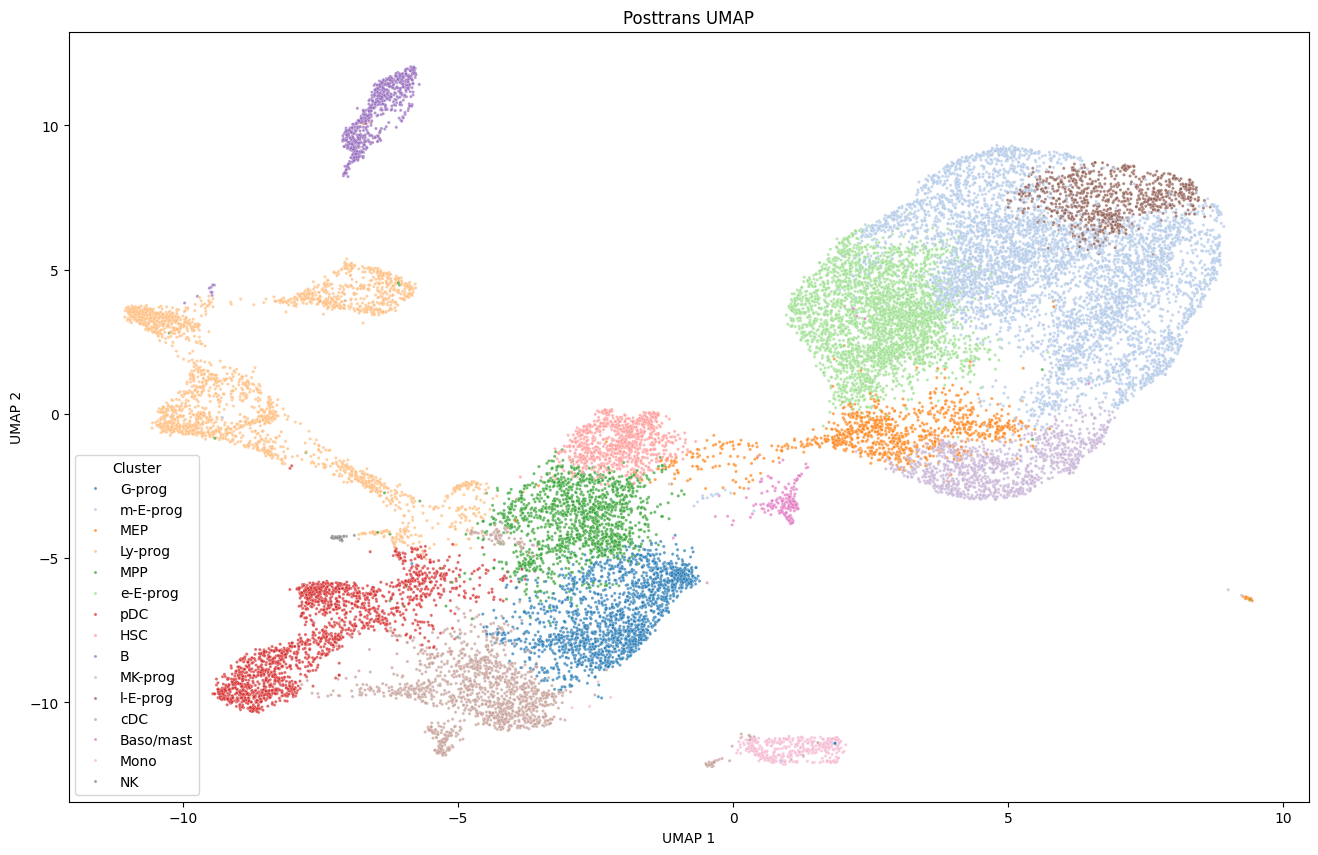

In [6]:
plt.figure(figsize=(16, 10))

sns.scatterplot(
    x=umap_coords.iloc[:, 0], 
    y=umap_coords.iloc[:, 1], 
    hue=umap_coords["seurat_post_scn_lineages"], 
    palette="tab20", 
    s=5, alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Posttrans UMAP")
plt.legend(title = "Cluster")
plt.show()

In [8]:
starCAT_usage = pd.read_csv("seu_common_starCAT.rf_usage_normalized.txt", sep = "\t", index_col = 0, header = 0)

starCAT_usage

,1,2,3,4,5,6,7,8,9,10,...,26,27,28,29,30,31,32,33,34,35
A_AAACGCTTCACTTGTT_A_pos_A_pos,0.093233,0.002983,1.007883e-06,0.071942,3.168081e-07,1.104624e-05,2.729468e-05,1.530325e-02,2.887512e-05,4.225398e-05,...,0.041570,0.000314,5.617971e-03,4.715390e-03,0.162382,0.014679,0.001075,0.172153,0.005786,0.000963
A_AAAGGATCAATGCAGG_A_pos_A_pos,0.000019,0.024977,2.066611e-03,0.104109,4.819354e-03,1.020830e-05,5.619262e-07,8.505099e-03,1.025460e-05,1.577434e-05,...,0.007069,0.004421,3.998445e-04,1.298720e-04,0.001893,0.023042,0.087538,0.152262,0.000647,0.020365
A_AAAGGATGTGCGAGTA_A_pos_A_pos,0.050029,0.045443,1.854136e-06,0.097183,4.761877e-04,1.048748e-08,1.713639e-05,1.385656e-02,4.805179e-04,1.256192e-04,...,0.014255,0.027242,2.475500e-02,4.028287e-06,0.206693,0.019369,0.000562,0.002179,0.000879,0.000003
A_AAAGGATTCACTGATG_A_pos_A_pos,0.005042,0.007156,2.261961e-06,0.160692,5.459808e-04,1.103507e-03,5.911867e-09,2.269137e-03,5.826886e-06,4.155095e-07,...,0.014653,0.012651,4.264427e-09,4.316397e-05,0.000583,0.027664,0.095605,0.004965,0.000003,0.004142
A_AAAGGGCCACCCTCTA_A_pos_A_pos,0.017922,0.009738,2.513231e-08,0.084618,2.428389e-24,2.779396e-07,6.321625e-03,1.675521e-05,9.945856e-03,9.474745e-05,...,0.291919,0.002482,5.612074e-03,9.262026e-08,0.000716,0.025900,0.000094,0.237217,0.001411,0.001075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F_TTTGTTGGTAGTGTGG_F_pos_F_pos,0.000130,0.030876,1.065755e-07,0.141955,6.956002e-03,4.694195e-10,7.176214e-03,9.680703e-03,3.963080e-10,2.848825e-06,...,0.037077,0.058655,5.993486e-02,4.276030e-05,0.355804,0.018228,0.001809,0.004782,0.005120,0.000461
F_TTTGTTGGTCAAAGTA_F_pos_F_pos,0.000018,0.008421,1.232129e-06,0.095586,1.727367e-03,2.618918e-03,4.088021e-03,5.754242e-03,1.350653e-05,9.895808e-06,...,0.001412,0.004766,3.597015e-06,4.918452e-06,0.003093,0.007045,0.285547,0.227420,0.003048,0.000056
F_TTTGTTGGTGCCTAAT_F_pos_F_pos,0.000006,0.009393,1.087438e-06,0.163576,2.796283e-08,3.195401e-07,1.249458e-02,3.907116e-03,7.216329e-07,7.072587e-07,...,0.002582,0.001396,5.243459e-05,5.739284e-06,0.001052,0.024342,0.116925,0.344039,0.000233,0.000059
F_TTTGTTGTCCAAGGGA_F_pos_F_pos,0.000065,0.013538,9.262765e-03,0.029862,5.685936e-03,1.508813e-03,1.572923e-03,1.771933e-07,3.612074e-05,3.599196e-06,...,0.011235,0.016524,1.098512e-02,5.991645e-05,0.001877,0.008118,0.253052,0.225721,0.004533,0.007466


In [9]:
starCAT_coord = umap_coords.merge(starCAT_usage, left_index=True, right_index=True)

starCAT_coord

,umap_1,umap_2,seurat_post_scn_lineages,1,2,3,4,5,6,7,...,26,27,28,29,30,31,32,33,34,35
A_AAACGCTTCACTTGTT_A_pos_A_pos,-3.156499,-7.825476,G-prog,0.093233,0.002983,1.007883e-06,0.071942,3.168081e-07,1.104624e-05,2.729468e-05,...,0.041570,0.000314,5.617971e-03,4.715390e-03,0.162382,0.014679,0.001075,0.172153,0.005786,0.000963
A_AAAGGATCAATGCAGG_A_pos_A_pos,5.618103,0.757314,m-E-prog,0.000019,0.024977,2.066611e-03,0.104109,4.819354e-03,1.020830e-05,5.619262e-07,...,0.007069,0.004421,3.998445e-04,1.298720e-04,0.001893,0.023042,0.087538,0.152262,0.000647,0.020365
A_AAAGGATGTGCGAGTA_A_pos_A_pos,-2.468250,-6.764936,G-prog,0.050029,0.045443,1.854136e-06,0.097183,4.761877e-04,1.048748e-08,1.713639e-05,...,0.014255,0.027242,2.475500e-02,4.028287e-06,0.206693,0.019369,0.000562,0.002179,0.000879,0.000003
A_AAAGGATTCACTGATG_A_pos_A_pos,4.657690,-0.200323,MEP,0.005042,0.007156,2.261961e-06,0.160692,5.459808e-04,1.103507e-03,5.911867e-09,...,0.014653,0.012651,4.264427e-09,4.316397e-05,0.000583,0.027664,0.095605,0.004965,0.000003,0.004142
A_AAAGGGCCACCCTCTA_A_pos_A_pos,-7.245675,-2.105738,Ly-prog,0.017922,0.009738,2.513231e-08,0.084618,2.428389e-24,2.779396e-07,6.321625e-03,...,0.291919,0.002482,5.612074e-03,9.262026e-08,0.000716,0.025900,0.000094,0.237217,0.001411,0.001075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F_TTTGTTGGTAGTGTGG_F_pos_F_pos,-1.371484,-5.672802,G-prog,0.000130,0.030876,1.065755e-07,0.141955,6.956002e-03,4.694195e-10,7.176214e-03,...,0.037077,0.058655,5.993486e-02,4.276030e-05,0.355804,0.018228,0.001809,0.004782,0.005120,0.000461
F_TTTGTTGGTCAAAGTA_F_pos_F_pos,5.822472,6.630932,l-E-prog,0.000018,0.008421,1.232129e-06,0.095586,1.727367e-03,2.618918e-03,4.088021e-03,...,0.001412,0.004766,3.597015e-06,4.918452e-06,0.003093,0.007045,0.285547,0.227420,0.003048,0.000056
F_TTTGTTGGTGCCTAAT_F_pos_F_pos,5.433661,3.936359,m-E-prog,0.000006,0.009393,1.087438e-06,0.163576,2.796283e-08,3.195401e-07,1.249458e-02,...,0.002582,0.001396,5.243459e-05,5.739284e-06,0.001052,0.024342,0.116925,0.344039,0.000233,0.000059
F_TTTGTTGTCCAAGGGA_F_pos_F_pos,7.540827,5.809652,m-E-prog,0.000065,0.013538,9.262765e-03,0.029862,5.685936e-03,1.508813e-03,1.572923e-03,...,0.011235,0.016524,1.098512e-02,5.991645e-05,0.001877,0.008118,0.253052,0.225721,0.004533,0.007466


In [10]:
geps = ["1", "4", "6", "14", "25", "26", "28", "30", "32"]

In [11]:
interest_geps = starCAT_coord[geps]

interest_geps

,1,4,6,14,25,26,28,30,32
A_AAACGCTTCACTTGTT_A_pos_A_pos,0.093233,0.071942,1.104624e-05,7.649383e-06,2.390025e-03,0.041570,5.617971e-03,0.162382,0.001075
A_AAAGGATCAATGCAGG_A_pos_A_pos,0.000019,0.104109,1.020830e-05,2.316680e-02,1.790378e-03,0.007069,3.998445e-04,0.001893,0.087538
A_AAAGGATGTGCGAGTA_A_pos_A_pos,0.050029,0.097183,1.048748e-08,2.797120e-05,2.365692e-04,0.014255,2.475500e-02,0.206693,0.000562
A_AAAGGATTCACTGATG_A_pos_A_pos,0.005042,0.160692,1.103507e-03,3.638715e-03,1.051010e-04,0.014653,4.264427e-09,0.000583,0.095605
A_AAAGGGCCACCCTCTA_A_pos_A_pos,0.017922,0.084618,2.779396e-07,1.192710e-03,4.002847e-07,0.291919,5.612074e-03,0.000716,0.000094
...,...,...,...,...,...,...,...,...,...
F_TTTGTTGGTAGTGTGG_F_pos_F_pos,0.000130,0.141955,4.694195e-10,9.316903e-06,4.506240e-03,0.037077,5.993486e-02,0.355804,0.001809
F_TTTGTTGGTCAAAGTA_F_pos_F_pos,0.000018,0.095586,2.618918e-03,8.248253e-07,4.483761e-05,0.001412,3.597015e-06,0.003093,0.285547
F_TTTGTTGGTGCCTAAT_F_pos_F_pos,0.000006,0.163576,3.195401e-07,7.789431e-07,7.291862e-04,0.002582,5.243459e-05,0.001052,0.116925
F_TTTGTTGTCCAAGGGA_F_pos_F_pos,0.000065,0.029862,1.508813e-03,9.450815e-05,1.788465e-04,0.011235,1.098512e-02,0.001877,0.253052


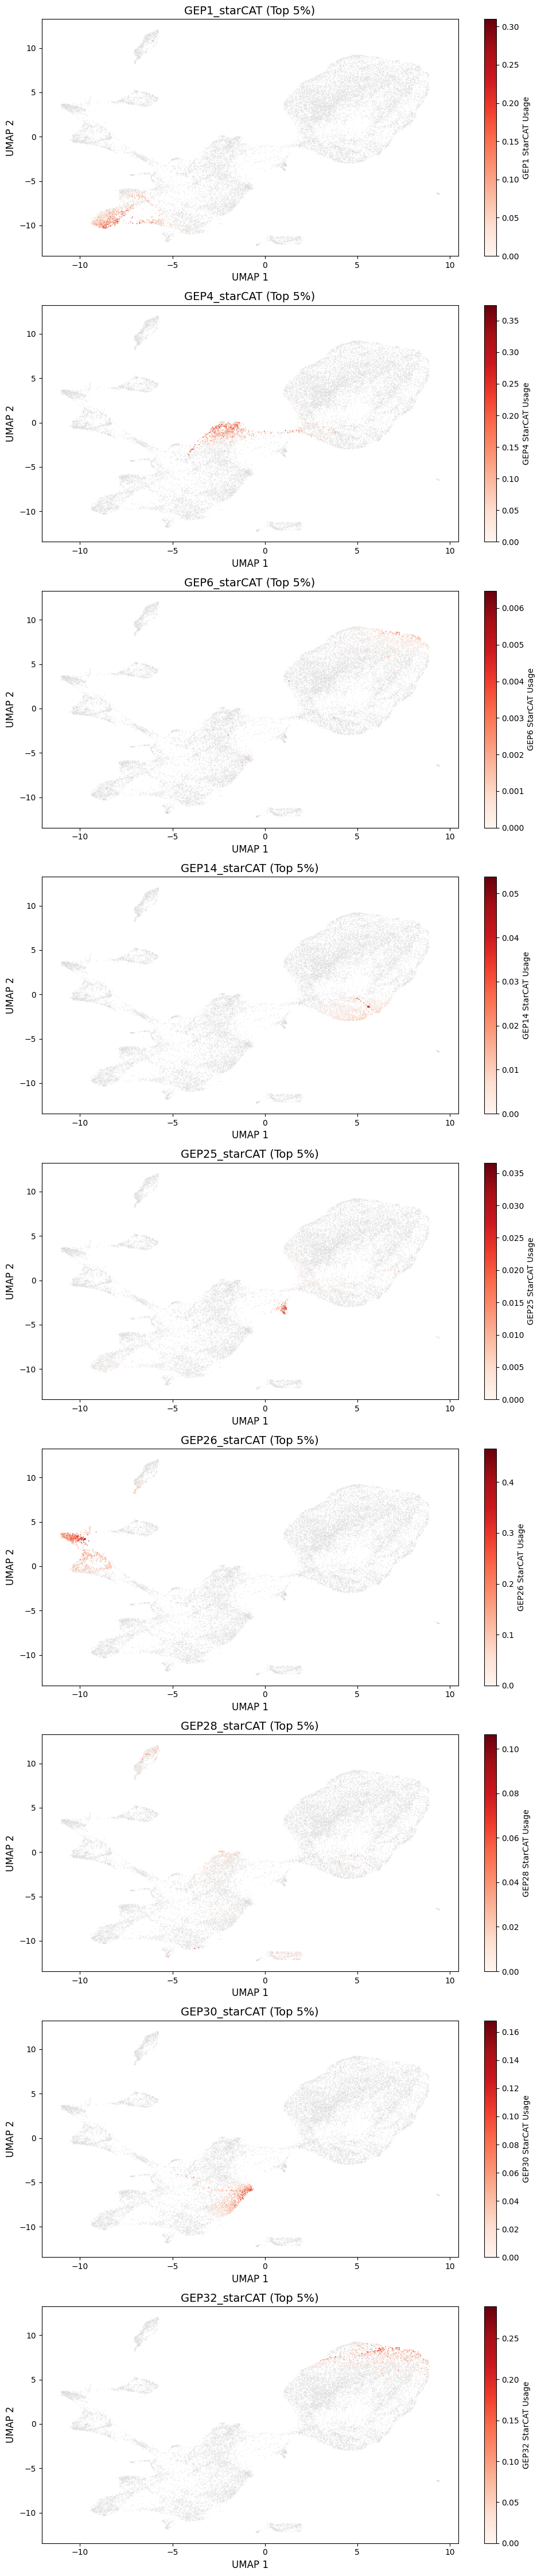

In [12]:
geps = ["1", "4", "6", "14", "25", "26", "28", "30", "32"]

fig, axes = plt.subplots(len(geps), 1, figsize=(10, len(geps) * 5))

for i, gep in enumerate(geps):
    percentile_95_starCAT = np.percentile(starCAT_coord[gep], 95)

    starCAT_coord[f"GEP{gep}_heat_starCAT"] = np.where(
        starCAT_coord[gep] >= percentile_95_starCAT, starCAT_coord[gep], np.nan
    )

    ax = axes[i]

    sns.scatterplot(
        data=starCAT_coord, x="umap_1", y="umap_2",
        color="lightgrey", alpha=0.5, s=1, ax=ax
    )

    scatter = sns.scatterplot(
        data=starCAT_coord, x="umap_1", y="umap_2",
        hue=f"GEP{gep}_heat_starCAT", palette="Reds",
        edgecolor=None, s=1, ax=ax, legend=False
    )

    norm = plt.Normalize(vmin=0, vmax=percentile_95_starCAT)
    sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(f"GEP{gep} StarCAT Usage")

    ax.set_title(f"GEP{gep}_starCAT (Top 5%)", fontsize=14)
    ax.set_xlabel("UMAP 1", fontsize=12)
    ax.set_ylabel("UMAP 2", fontsize=12)

plt.tight_layout()
plt.show()